In [2]:
import numpy as np
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from tqdm.notebook import tqdm

# from modulars.plot_rr import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars import run_restart_multid, gaussian_multid
from modulars.distributions import gaussian_multid_posterior, ensure_arr
from modulars.utils import check_all_int_or_float_or_1darrays, check_all_covar_shaped_arrays
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDiagonalNormal
from numpyro.optim import Adam
import numpyro.distributions as dist

In [3]:
# this is 40 dimensions
mu_prior = np.zeros(40)
sigma_prior = np.ones(40) * 10 # diag std of prior
mu_like = 2.0
sigma_like = 1.0 # std of likelihood
max_iters = 200_000
n_obs = 3
dim = 40
np.random.seed(42)

DIAG = True

# Generate observations for each dimension
observed_data = gaussian_multid(
    seed=42, n_samples=n_obs, mu_like=mu_like,
    scale_like=sigma_like, dim=dim)
# compute known posterior,this is the posterior 
# diagonal standard deviation vector as true_sigma_post
true_mu_post, true_sigma_post = gaussian_multid_posterior(
    observed_data, n_samples=n_obs,
    mu_prior=mu_prior, scale_prior=sigma_prior,
    scale_like=1.0, std_devs=True,
    diag=DIAG, dim=40)

In [4]:
if DIAG:
    print("Running diagonal covariance case")
    # this runs the easiest case where all dimensions are i.i.d.
    # note that this assumes the input parameters are standard deviations
    # only run this cell if diag is True and all of the parameters are floats or 1d arrays
    assert DIAG, "this code only works for diagonal covariance matrices"
    assert check_all_int_or_float_or_1darrays(mu_prior, sigma_prior, mu_like, sigma_like), "all parameters must be floats or 1d arrays"

    def model(y=None):
        mu = numpyro.sample('mu',
            dist.MultivariateNormal(
                loc = ensure_arr(mu_prior, dim),
                covariance_matrix=jnp.diag(ensure_arr(sigma_prior**2, dim)))
        )
        numpyro.sample('z',
            dist.MultivariateNormal(
                loc = mu,
                covariance_matrix = jnp.diag(ensure_arr(sigma_like**2, dim))),
            obs=y
        )

Running diagonal covariance case


In [5]:
if not DIAG:
    print ("Running non-diagonal covariance case")
    # this is if we have non-diagonal covariance matrices,
    # which means that we need the full covariance matrices
    # inputs should be 2d arrays of shape (dim, dim)
    assert check_all_covar_shaped_arrays(dim, sigma_prior, sigma_like), "must input correctly shaped ({dim}, {dim})covariance matrices"
    def model(y=None):
        mu = numpyro.sample('mu',
            dist.MultivariateNormal(
                loc = ensure_arr(mu_prior, dim), covariance_matrix=sigma_prior)
        )
        numpyro.sample('z',
            dist.MultivariateNormal(
                loc = mu, covariance_matrix = sigma_like),
            obs=y
        )

In [ ]:
results = []
for seed in tqdm(range(50)):
    result = run_restart_multid(
        seed, model, observed_data, 'mu', 100_000,
        dim=40
        )
    results.append(result)


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
from modulars.utils import apply_traj_transform_multid
single_means, single_stds, multi_means, multi_stds = \
    apply_traj_transform_multid(results)


  0%|          | 0/50 [00:00<?, ?it/s]

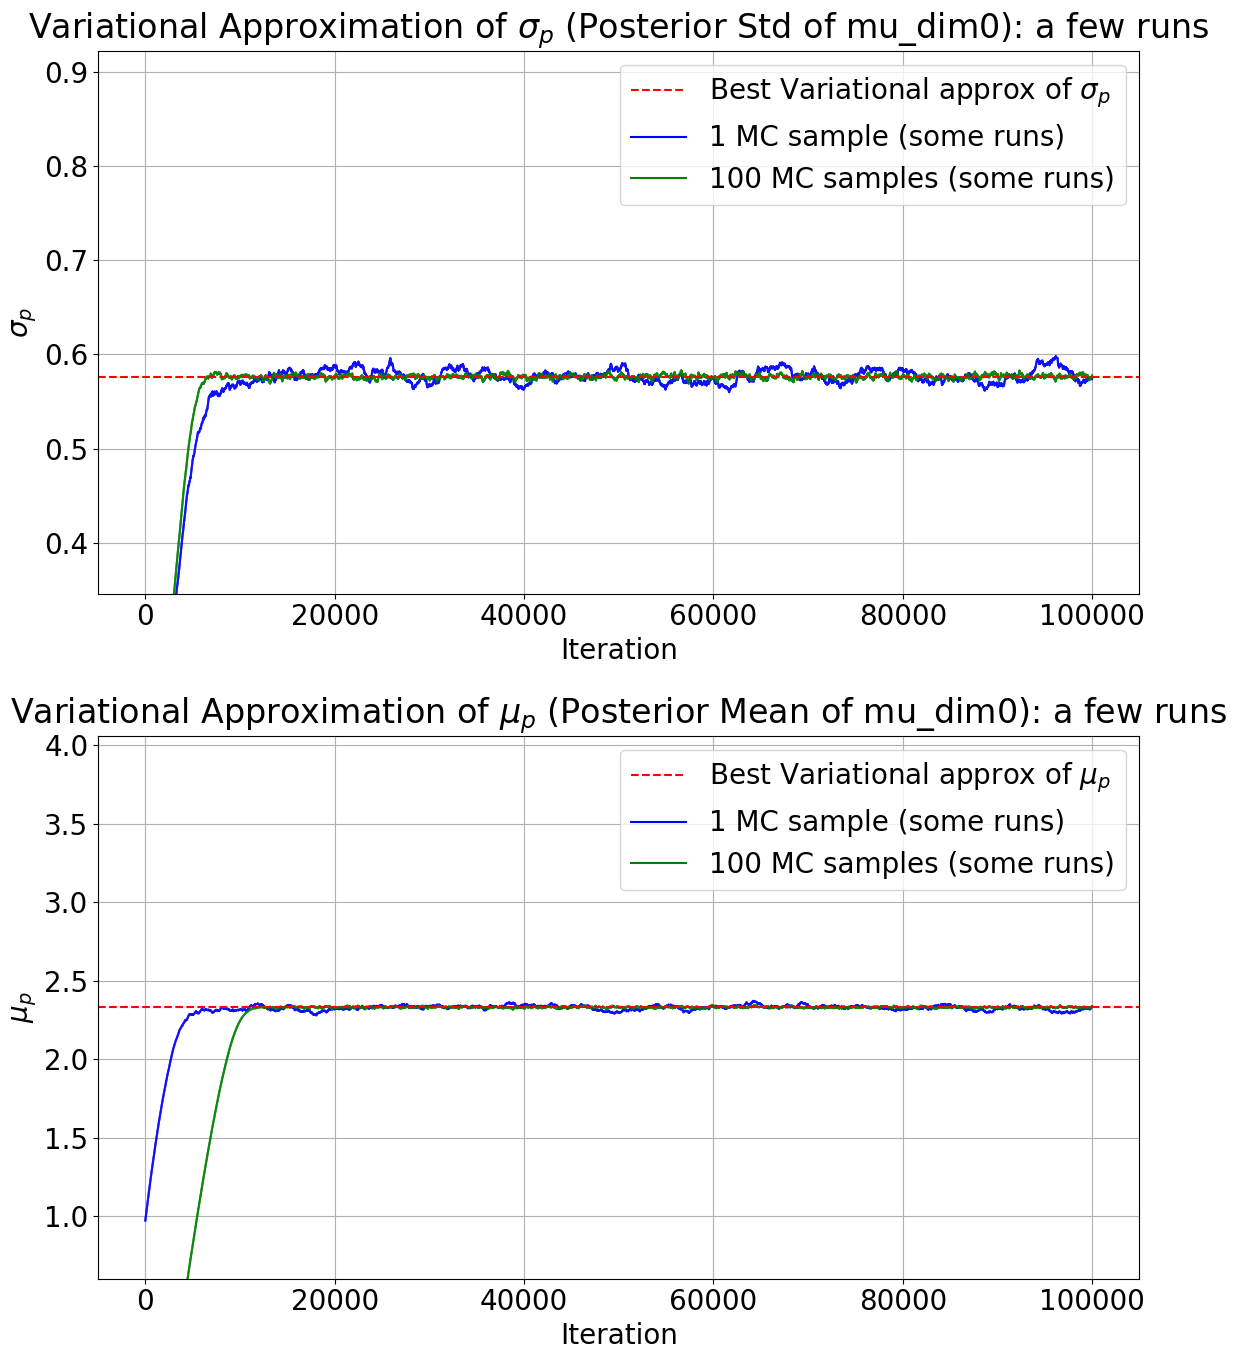

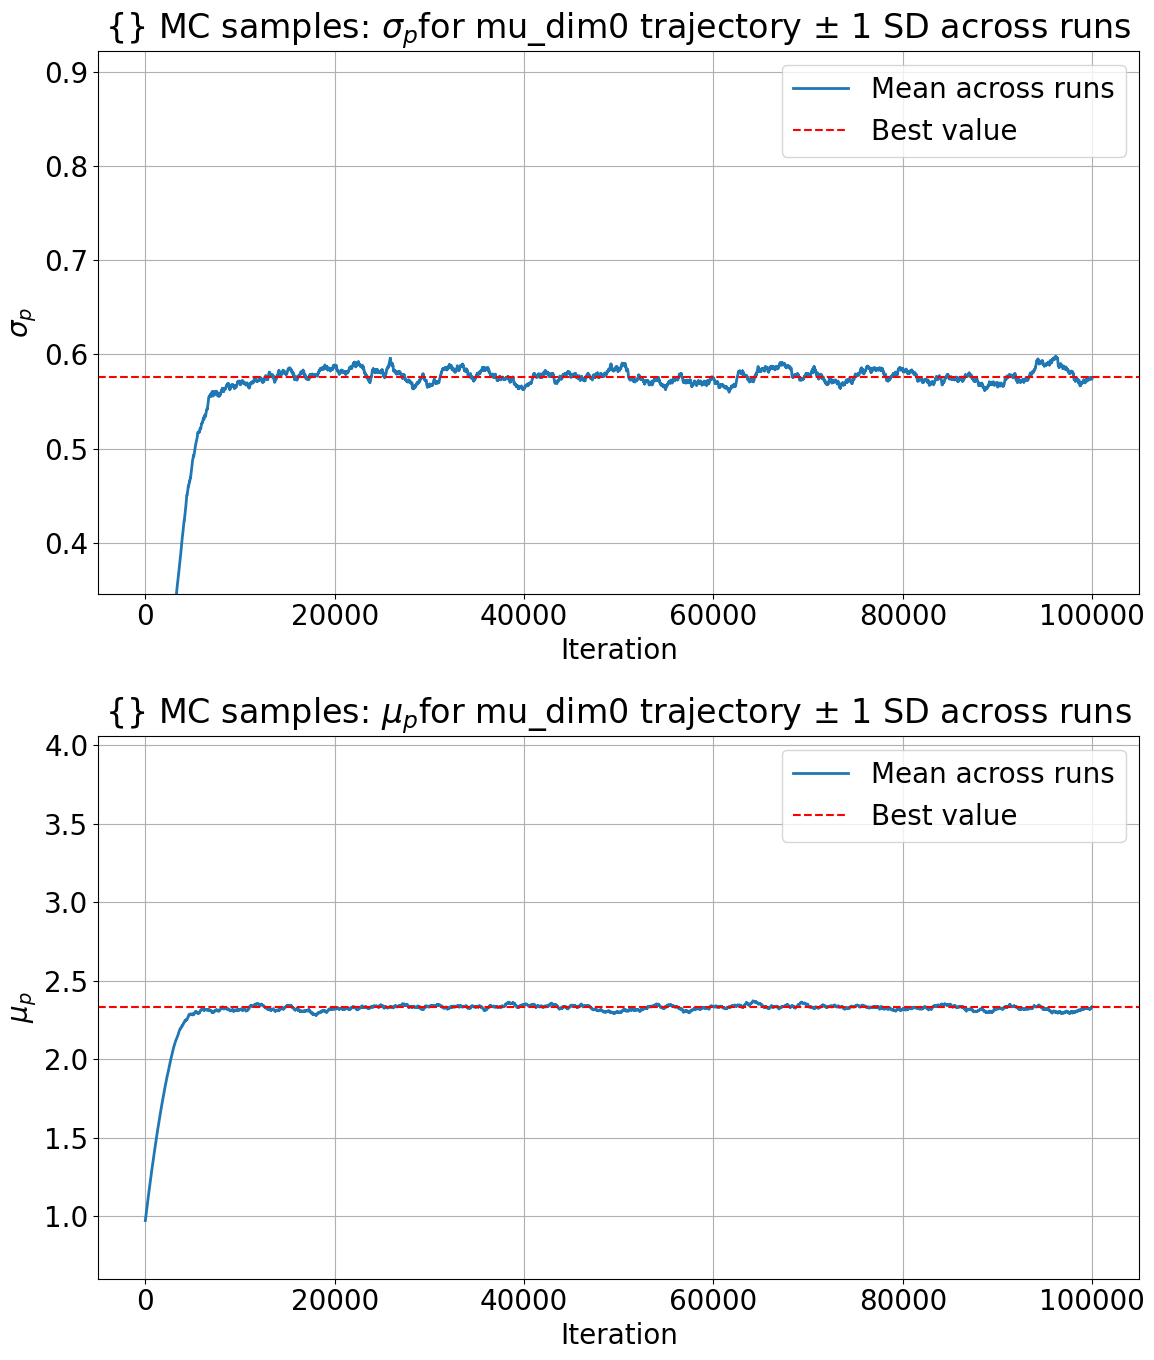

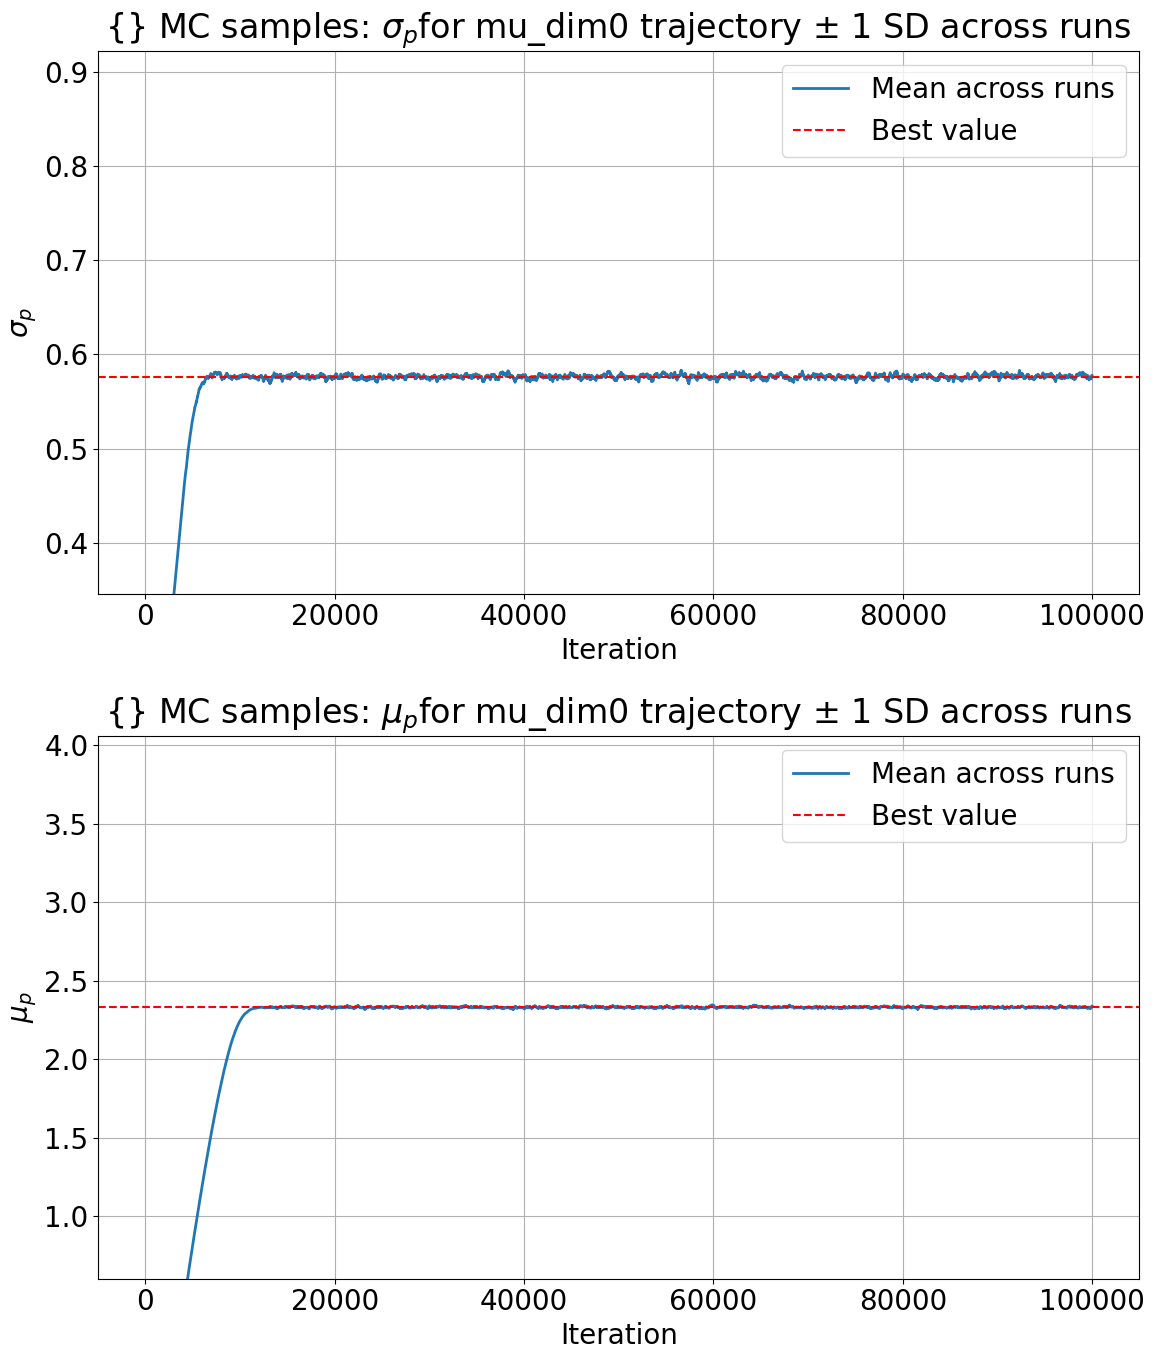

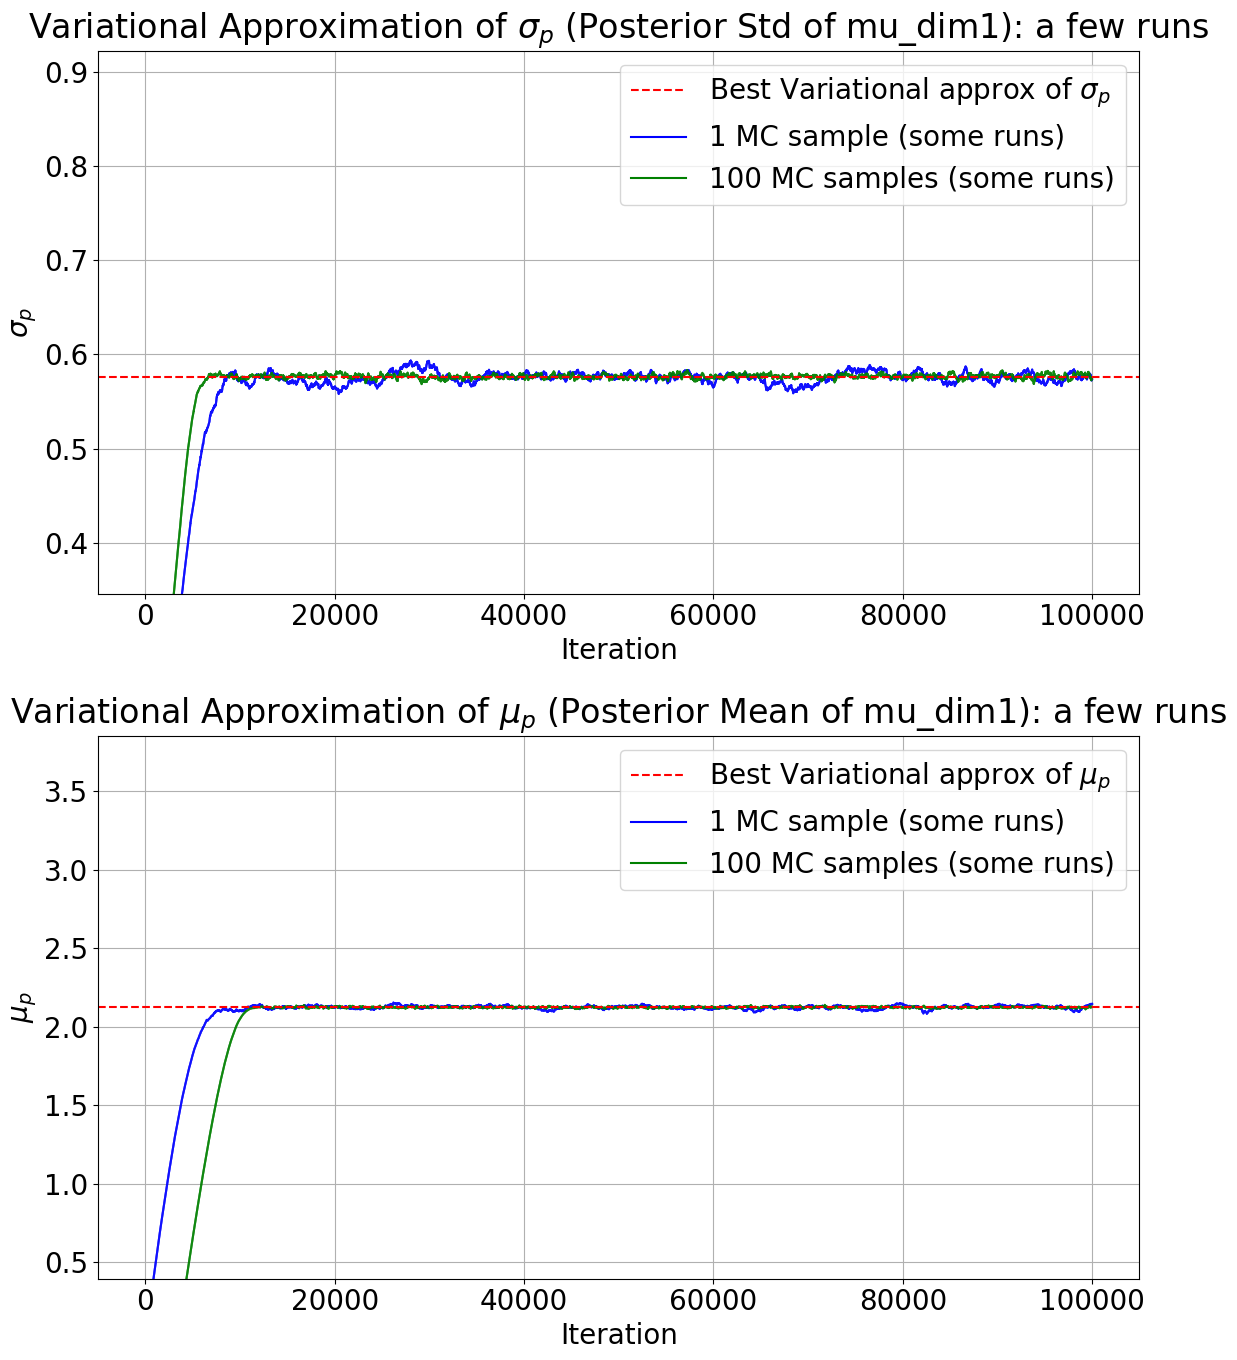

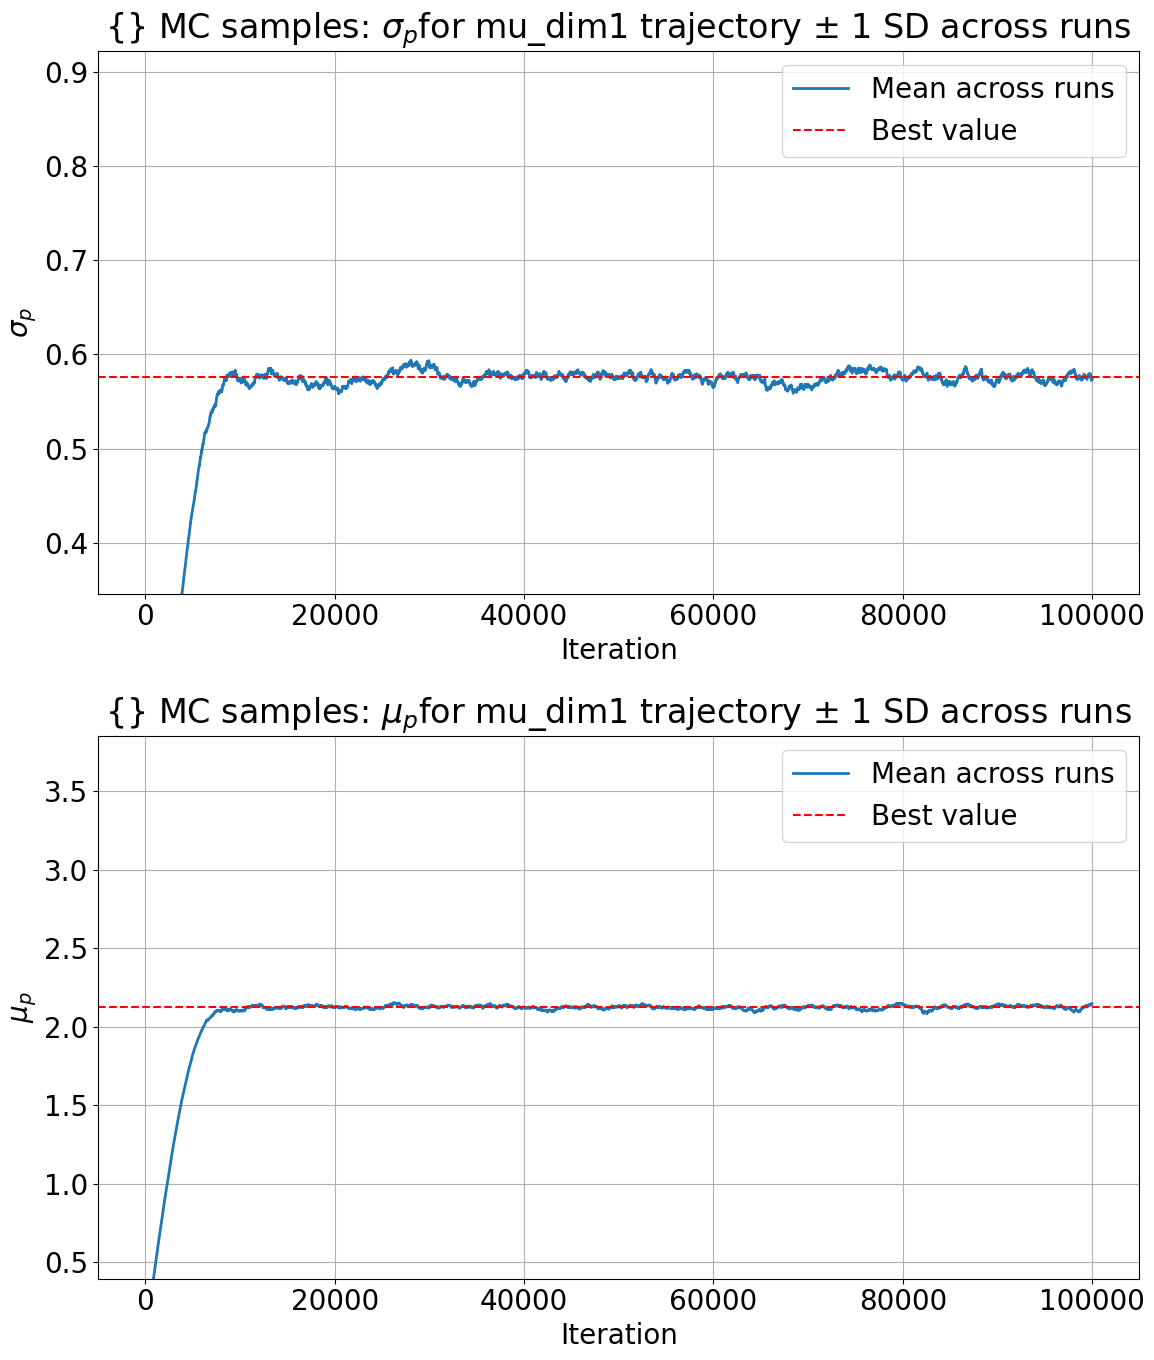

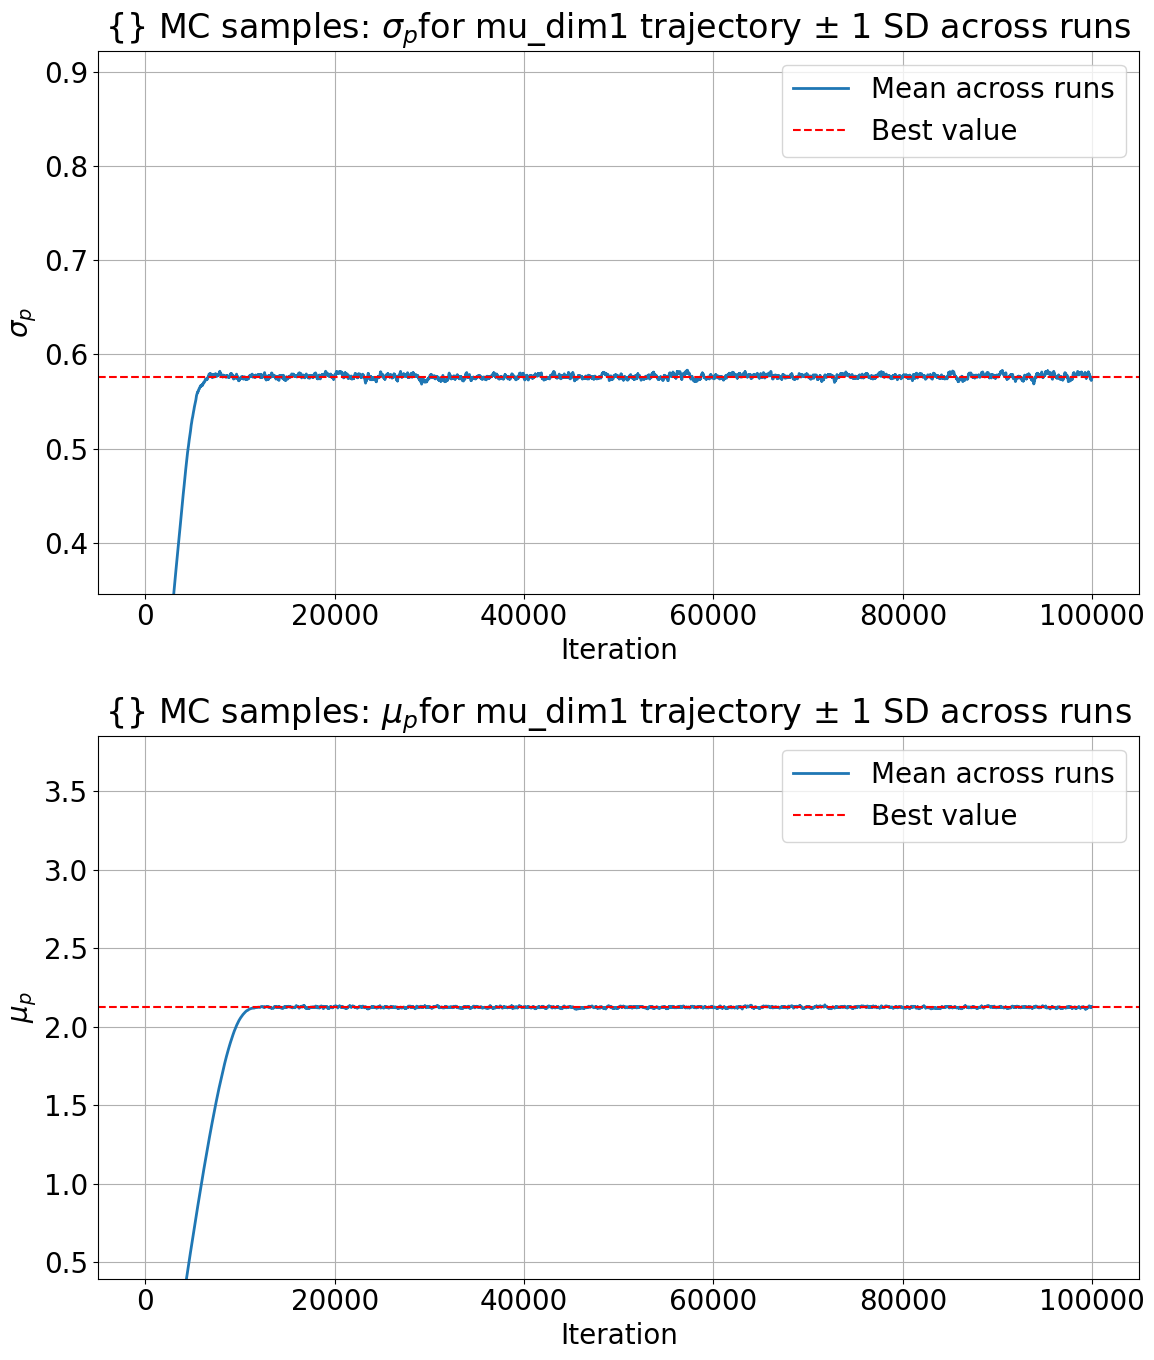

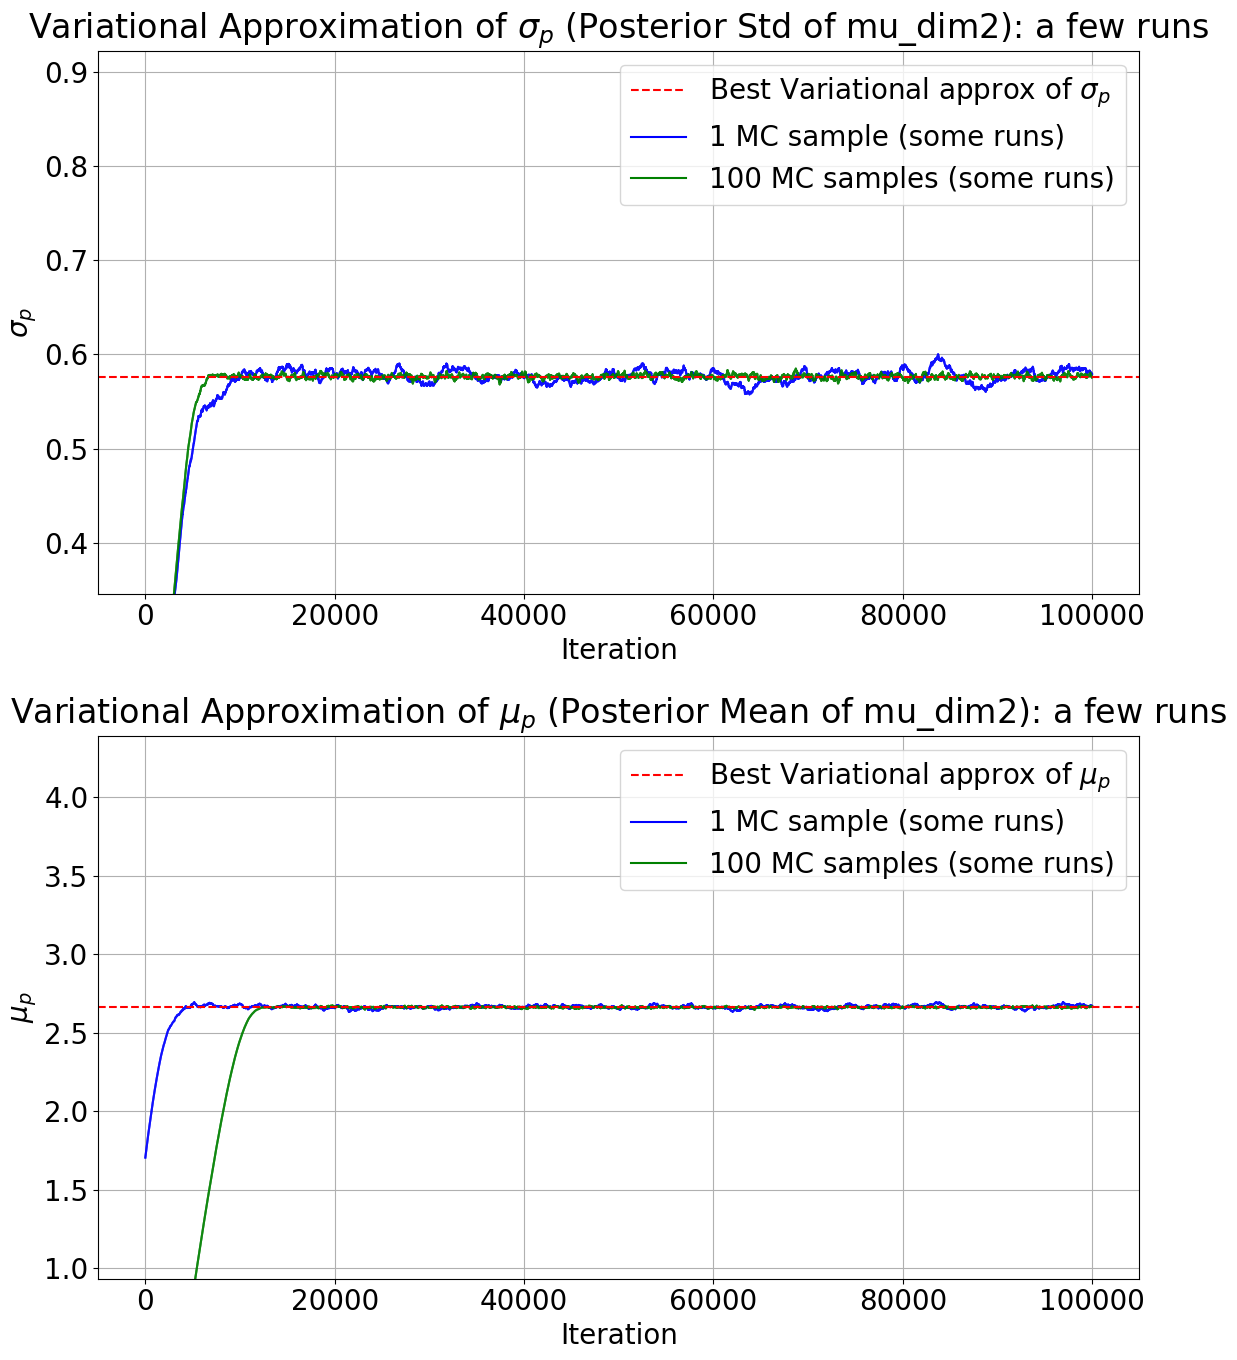

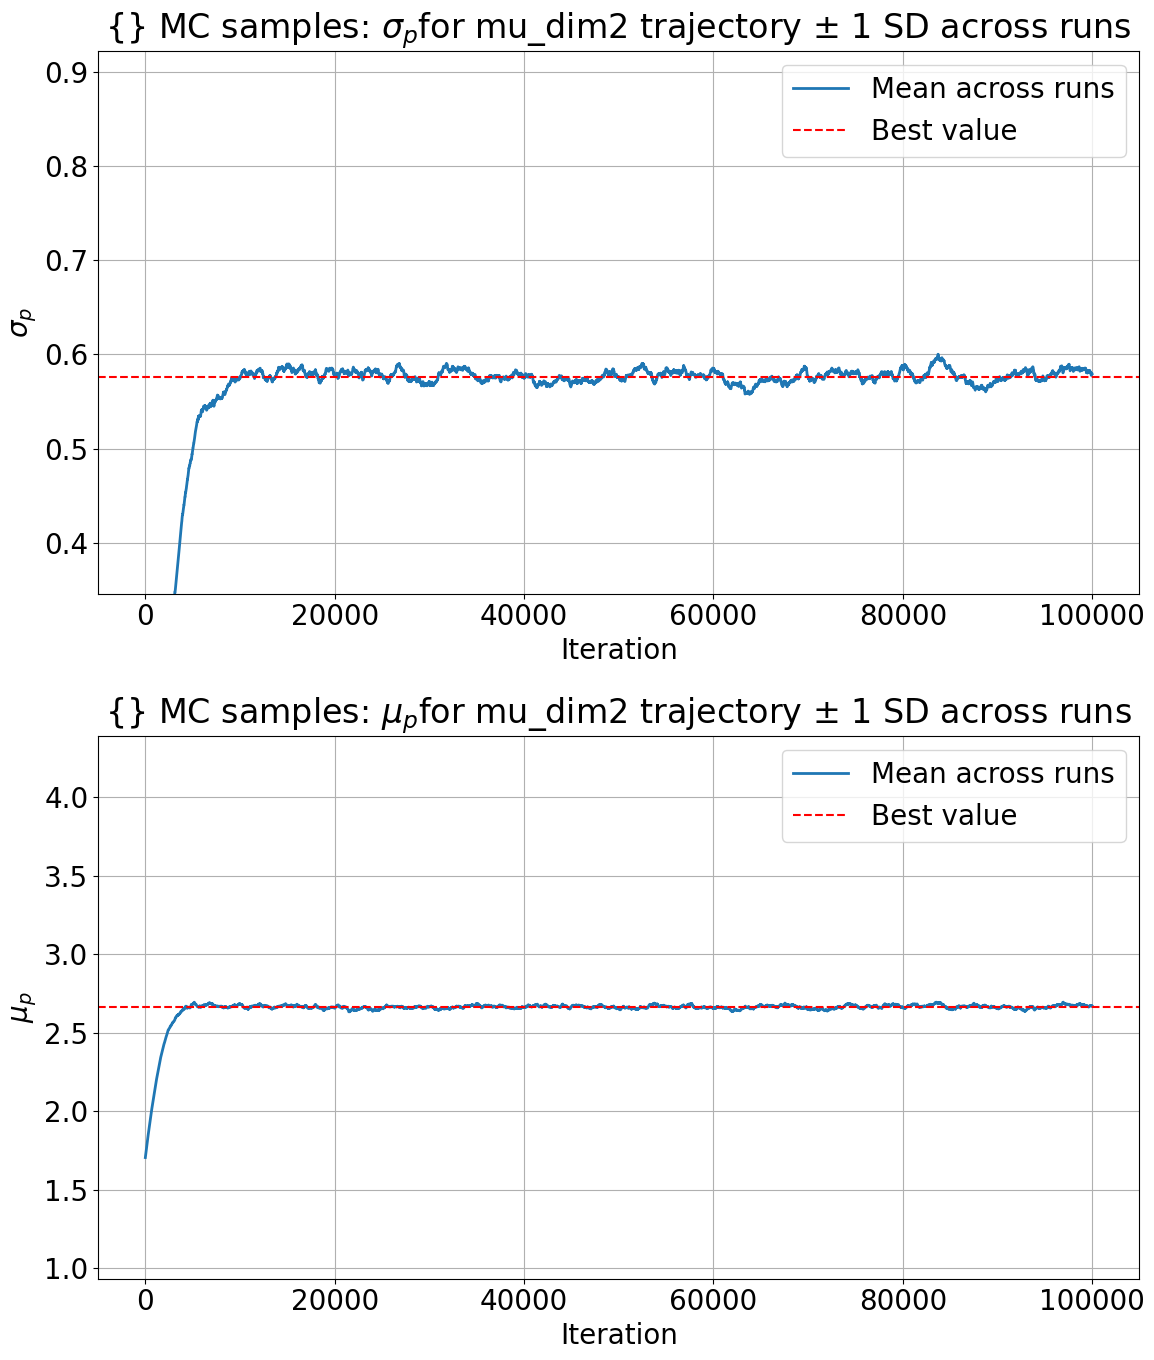

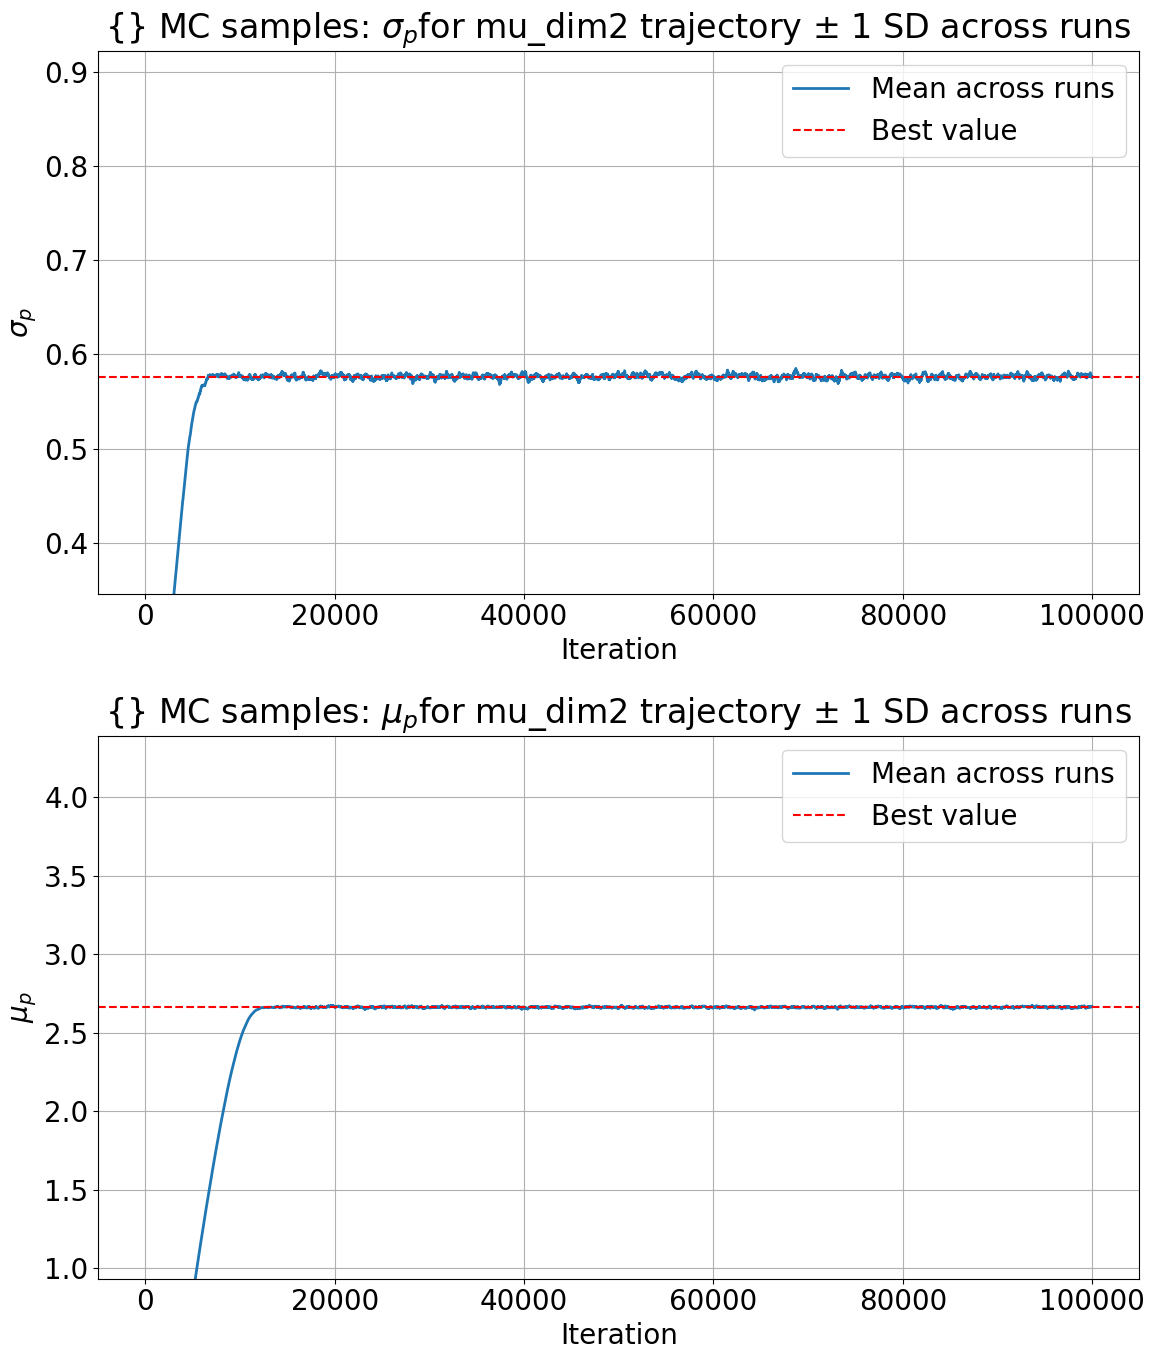

In [ ]:

from modulars.plot_rr import plot_some_dims_multid
which_dims = [0, 1, 2]
plot_some_dims_multid(
    single_means, single_stds, multi_means, multi_stds,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3
)

In [ ]:
single_means.shape

NameError: name 'single_means' is not defined

In [ ]:
len(results)

50

In [ ]:
len(results[0])

4

In [ ]:
np.stack(results[0], axis=0).shape

(4, 100000, 40)